# 📉 İstatistiksel Süreç Kontrolü (SPC) — İnteraktif Defter

Bir imalat sürecinden alt gruplar halinde alınan ölçümlerle **X-bar** ve **R** kontrol grafiklerini kurup **kontrol dışı** noktaları tespit ediyoruz.

> Ağır hesaplar `src/spc.py` modülünden içe aktarılır (modüler kod).

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, 'src')
from spc import alt_grup_istatistikleri, kontrol_limitleri, kontrol_disi_isaretle

df = pd.read_csv('veri/olcum_verileri.csv')
print('Ölçüm sayısı:', len(df), '| Alt grup:', df['alt_grup'].nunique())
df.head()

Ölçüm sayısı: 150 | Alt grup: 30


,alt_grup,olcum_no,olcum_mm
0,1,1,25.0514
1,1,2,25.0821
2,1,3,25.0573
3,1,4,24.9513
4,1,5,24.9304


## 1. Alt Grup İstatistikleri

Her alt grup için ortalama (**X-bar**) ve değer aralığı (**R**) hesaplanır.

In [2]:
ozet = alt_grup_istatistikleri(df)
ozet.head()

,alt_grup,x_bar,r_deger
0,1,25.01450,0.1517
1,2,25.04000,0.0871
2,3,25.00332,0.1296
3,4,24.96932,0.1094
4,5,24.98386,0.1192


## 2. Kontrol Limitleri ve Kontrol Dışı Noktalar

Standart Shewhart sabitleriyle (A2, D3, D4) limitler hesaplanır.

In [3]:
lim = kontrol_limitleri(ozet, n=5)
ozet = kontrol_disi_isaretle(ozet, lim)
for k, v in lim.items():
    print(f'{k:10s}: {v:.4f}')
print('\nX-bar kontrol dışı:', ozet.loc[ozet['x_kontrol_disi'],'alt_grup'].tolist())
print('R kontrol dışı    :', ozet.loc[ozet['r_kontrol_disi'],'alt_grup'].tolist())

x_merkez  : 25.0175
x_ucl     : 25.0967
x_lcl     : 24.9384
r_merkez  : 0.1372
r_ucl     : 0.2900
r_lcl     : 0.0000

X-bar kontrol dışı: [29]
R kontrol dışı    : [27, 28, 29]


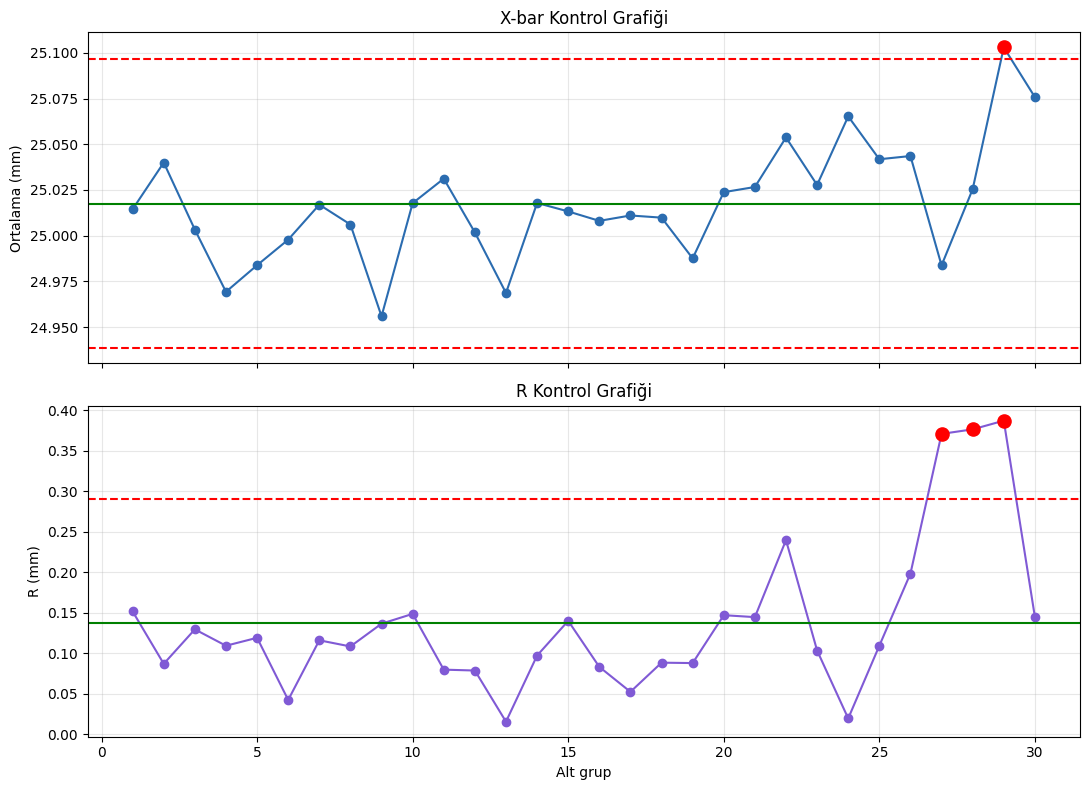

In [4]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
a1.plot(ozet['alt_grup'], ozet['x_bar'], marker='o', color='#2b6cb0')
a1.axhline(lim['x_merkez'], color='green'); a1.axhline(lim['x_ucl'], color='red', ls='--')
a1.axhline(lim['x_lcl'], color='red', ls='--')
d = ozet[ozet['x_kontrol_disi']]; a1.scatter(d['alt_grup'], d['x_bar'], color='red', s=90, zorder=5)
a1.set_title('X-bar Kontrol Grafiği'); a1.set_ylabel('Ortalama (mm)'); a1.grid(alpha=0.3)
a2.plot(ozet['alt_grup'], ozet['r_deger'], marker='o', color='#805ad5')
a2.axhline(lim['r_merkez'], color='green'); a2.axhline(lim['r_ucl'], color='red', ls='--')
dr = ozet[ozet['r_kontrol_disi']]; a2.scatter(dr['alt_grup'], dr['r_deger'], color='red', s=90, zorder=5)
a2.set_title('R Kontrol Grafiği'); a2.set_xlabel('Alt grup'); a2.set_ylabel('R (mm)'); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. 🤔 Neden Burada Makine Öğrenmesi Yok?

SPC, doğası gereği **istatistiksel** bir yöntemdir ve az veriyle bile güvenilir, **yorumlanabilir** sonuç verir. 30 alt gruplu bu veri setinde bir ML modeli aşırı öğrenmeye (overfitting) çok yatkın olurdu.

**Doğru araç seçimi mühendisliğin bir parçasıdır:** her probleme ML uygulamak yerine, kalite kontrolde kanıtlanmış Shewhart yöntemini kullanmak daha profesyonel bir tercihtir. (ML'in doğal olduğu yerler için Proje 1, 2 ve 4'e bakın.)

## ✅ Sonuç

Kontrol grafikleri, sürece bilerek enjekte edilen **ortalama kayması** (20. alt gruptan sonra) ve **değişkenlik artışını** (25. alt gruptan sonra) başarıyla yakaladı. Süreç, son alt gruplarda kontrol dışına çıkıyor.